In [1]:
# BOOK_FIGURE_STYLE_CELL
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

try:
    import seaborn as sns
except ImportError:
    sns = None

try:
    import matplotlib_inline

    matplotlib_inline.backend_inline.set_matplotlib_formats("svg", "pdf")
except Exception:
    matplotlib_inline = None

FIGURE_SIZES = {
    "full_landscape": (4.50, 2.65),
    "full_standard": (4.50, 3.15),
    "full_tall": (4.50, 4.20),
    "half_standard": (3.55, 2.55),
    "half_tall": (3.55, 3.05),
    "inset": (2.30, 1.75),
}

BOOK_COLORS = {
    "blue": "#4C78A8",
    "orange": "#F58518",
    "green": "#54A24B",
    "red": "#E45756",
    "gray": "#7F7F7F",
}

BOOK_TARGET = "web"


def setup_book_style(target="web"):
    global BOOK_TARGET
    BOOK_TARGET = target
    mpl.rcParams.update(
        {
            "figure.figsize": FIGURE_SIZES["half_standard"],
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.02,
            "font.family": "sans-serif",
            "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
            "axes.labelsize": 9,
            "axes.titlesize": 9,
            "axes.linewidth": 0.8,
            "axes.grid": False,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "xtick.major.width": 0.8,
            "ytick.major.width": 0.8,
            "legend.fontsize": 8,
            "legend.frameon": False,
            "lines.linewidth": 1.5,
            "lines.markersize": 4,
            "patch.linewidth": 0.8,
            "image.cmap": "gray",
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
        }
    )
    if target == "latex":
        try:
            mpl.rcParams["text.usetex"] = False
        except Exception:
            mpl.rcParams["text.usetex"] = False


def new_figure(
    size="half_standard",
    nrows=1,
    ncols=1,
    sharex=False,
    sharey=False,
    constrained=True,
    squeeze=True,
    **kwargs,
):
    fig, ax = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        sharex=sharex,
        sharey=sharey,
        constrained_layout=constrained,
        figsize=FIGURE_SIZES[size],
        squeeze=squeeze,
        **kwargs,
    )
    return fig, ax


def label_panels(axes=None, labels=None, x=0.02, y=0.98, **kwargs):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    if labels is None:
        labels = [f"({chr(97 + i)})" for i in range(len(axes))]
    default = dict(
        fontsize=9,
        fontweight="bold",
        va="top",
        ha="left",
        transform=None,
    )
    default.update(kwargs)
    for ax, label in zip(axes, labels):
        call_kwargs = dict(default)
        if call_kwargs["transform"] is None:
            call_kwargs["transform"] = ax.transAxes
        ax.text(x, y, label, **call_kwargs)


def finalize_axes(axes=None, keep_box=False, grid=False):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        if grid:
            ax.grid(axis="y", color="0.88", linewidth=0.6)
        else:
            ax.grid(False)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
        if keep_box:
            ax.spines["top"].set_visible(True)
            ax.spines["right"].set_visible(True)
        else:
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
    return axes


def save_book_figure(fig, basename, target="web", pdf=True, png=False):
    base = Path(basename)
    base.parent.mkdir(parents=True, exist_ok=True)
    if pdf:
        fig.savefig(base.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    if png:
        fig.savefig(base.with_suffix(".png"), bbox_inches="tight", pad_inches=0.02)


setup_book_style(target="web")


# Stochastic exponential growth


Stochastic exponential growth, also called geometric Brownian motion (GBM), is a simple model for a positive quantity that grows or decays while experiencing random fluctuations. The model is

$$
dX_t = \mu X_t\,dt + \sigma X_t\,dW_t,\qquad X_0>0,
$$

where $X_t$ is the state at time $t$, $\mu$ is its deterministic growth rate, $\sigma>0$ controls the strength of the fluctuations, and $W_t$ is a Wiener process.

We use a processed table of cancer-cell population trajectories reported by {cite:t}`johnson2019cancer`. That study develops richer discrete population models, including an Allee effect. Our purpose is narrower: to use the measurements to examine what this deliberately simple continuous GBM baseline can and cannot reproduce.



In [2]:
import hashlib
from io import BytesIO
from urllib.request import urlopen

import jax
from jax import lax
import jax.numpy as jnp
import jax.random as jr
import jax.scipy.stats as jss
import pandas as pd

jax.config.update("jax_enable_x64", True)

# Prefer the bundled data. The immutable fallback keeps the Colab notebook usable.
data_candidates = (
    Path("data/cancer_growth.csv"),
    Path("../../data/cancer_growth.csv"),
    Path("book/data/cancer_growth.csv"),
)
data_path = next((path for path in data_candidates if path.exists()), None)
if data_path is None:
    data_url = (
        "https://raw.githubusercontent.com/PredictiveScienceLab/"
        "advanced-scientific-machine-learning/"
        "1dfb996645d073152686e19ea082ae1dea6f4ec3/"
        "book/data/cancer_growth.csv"
    )
    data_bytes = urlopen(data_url).read()
else:
    data_bytes = data_path.read_bytes()
expected_sha256 = "95ee1a458ddc655e857373279e33d28d21997cf3afcd909717220e5dd7f7631b"
if hashlib.sha256(data_bytes).hexdigest() != expected_sha256:
    raise ValueError("The cancer-growth data do not match the reviewed version.")
data = pd.read_csv(BytesIO(data_bytes), header=None)

# Extract metadata
column_labels = data.iloc[0].values  # First row: Column names with prefixes
seed_info = data.iloc[1].values      # Second row: Seeding information

# Extract actual data
data_values = data.iloc[2:].reset_index(drop=True).astype(float)

# Initialize dictionaries for storing the time and cell count arrays
time_dict = {}
count_dict = {}

# Iterate over unique seed values
for seed in sorted(set(seed_info)):
    # Get columns belonging to the current seed
    seed_columns = [i for i, seed_val in enumerate(seed_info) if seed_val == seed]
    seed_labels = column_labels[seed_columns]
    
    # Identify time and count columns
    time_cols = [i for i, label in zip(seed_columns, seed_labels) if "time" in label]
    count_cols = [i for i, label in zip(seed_columns, seed_labels) if "time" not in label]
    
    # Assign JAX arrays for time and counts based on seed
    if time_cols:
        time_dict[seed] = jnp.array(data_values.iloc[:, time_cols].values)
    if count_cols:
        count_dict[seed] = jnp.array(data_values.iloc[:, count_cols].values)

# Extract the desired arrays
t2 = time_dict["n=2"][~jnp.isnan(time_dict["n=2"])]
t5 = time_dict["n=5"][~jnp.isnan(time_dict["n=5"])]
t12 = time_dict["n=12"][~jnp.isnan(time_dict["n=12"])]
P2 = count_dict["n=2"][:len(t2)]
P5 = count_dict["n=5"][:len(t5)]
P12 = count_dict["n=12"][:len(t12)]

## Data and model

The processed table contains three cohorts labeled $n=2$, $n=5$, and $n=12$. These are cohort labels rather than exact initial states: individual trajectories can begin at nearby cell counts. Each cohort contains repeated population measurements over time. The trajectories display both growth and substantial experiment-to-experiment variation.

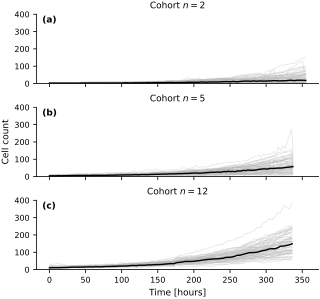

In [3]:
cohorts = ((t2, P2, "$n=2$"), (t5, P5, "$n=5$"), (t12, P12, "$n=12$"))
fig, axs = new_figure("full_tall", nrows=3, sharex=True, sharey=True)
for ax, (t_cohort, P_cohort, cohort_label) in zip(axs, cohorts):
    ax.plot(
        t_cohort, P_cohort, color="0.72", linewidth=0.45, alpha=0.65,
        rasterized=True,
    )
    ax.plot(
        t_cohort, np.nanmedian(np.asarray(P_cohort), axis=1),
        color="black", linewidth=1.4,
    )
    ax.set_title(f"Cohort {cohort_label}")
    ax.set_ylim(0, 400)
axs[1].set_ylabel("Cell count")
axs[-1].set_xlabel("Time [hours]")
label_panels(axs)
finalize_axes(axs, keep_box=False)
plt.show()

## Direct-state approximation

For a time step $h>0$, Euler--Maruyama approximates the GBM dynamics by

$$
X_{t+h} \approx X_t + \mu X_t h + \sigma X_t \sqrt{h} Z,
$$

where $Z\sim\mathcal{N}(0,1)$. Equivalently, the one-step increment satisfies

$$
\Delta X_i \mid X_{t_i}=x \overset{\mathrm{EM}}{\approx} \mathcal{N}(\mu x h, \sigma^2 x^2 h).
$$

The superscript emphasizes that this is an approximation. A sufficiently large negative draw can make the Euler--Maruyama state negative even though the exact GBM remains positive. The following function implements this direct-state approximation.

In [4]:
# Define the Euler-Maruyama method
def euler_maruyama_step(carry, dt):
    """Perform a single step of the Euler-Maruyama method."""
    # Unpack the state
    key, mu, sigma, x0 = carry

    # Split the random key, we want iid samples each step
    key, subkey = jr.split(key)

    # Compute the drift term
    drift = mu * x0 * dt

    # Compute the diffusion term
    diffusion = sigma * x0 * jnp.sqrt(dt) * jr.normal(subkey)

    x1 = x0 + drift + diffusion

    return (key, mu, sigma, x1), x1

We first simulate one path with illustrative parameter values.

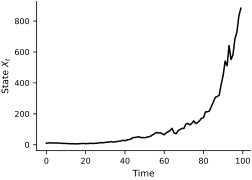

In [5]:
# Define the parameters and use a local key for reproducible output.
initial_key, path_key = jr.split(jr.PRNGKey(0))
X_0 = jr.uniform(initial_key, (), minval=1, maxval=10)
mu = 0.05
sigma = 0.1
time = jnp.arange(0, 100, 1.0)
dt = jnp.diff(time, axis=0)

init_carry = (path_key, mu, sigma, X_0)

_, X_t = lax.scan(euler_maruyama_step, init_carry, dt)

all_X = jnp.concatenate((jnp.atleast_1d(X_0), X_t))

# Plot the results
fig, ax = new_figure("half_standard")
ax.plot(time, all_X, color="black")
ax.set_xlabel("Time")
ax.set_ylabel("State $X_t$")
finalize_axes(ax, keep_box=False)
plt.show()

## Exact simulation in log space

The direct-state approximation is useful for illustrating Euler--Maruyama, but GBM has an exact transition. Define

$$
Y_t = \log X_t.
$$

Applying Itô's formula, as introduced in the preceding section, gives

$$
dY_t = \left(\mu - \frac{1}{2}\sigma^2\right)dt + \sigma\,dW_t.
$$

Consequently, for $h>0$ and $x>0$,

$$
Y_{t+h}\mid X_t=x \sim \mathcal{N}\left(\log x + \left(\mu-\frac{\sigma^2}{2}\right)h,\ \sigma^2h\right).
$$

Equivalently, $X_{t+h}\mid X_t=x$ is lognormally distributed. The log-space update is therefore exact at the selected time points when $\mu$ and $\sigma$ are constant, and exponentiation preserves positivity. We compare it with direct-state Euler--Maruyama using the same initial value and Gaussian innovations.

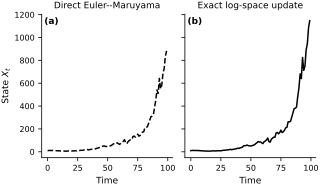

In [6]:
# Exact one-step update for the constant-coefficient log process
def exact_log_step(carry, dt):
    """Advance log-GBM exactly over one time interval."""
    # Unpack the state
    key, mu, sigma, y0 = carry

    # Split the random key for a fresh normal sample each step
    key, subkey = jr.split(key)

    # Compute the drift in log-space
    drift = (mu - 0.5 * sigma**2) * dt

    # Compute the diffusion term in log-space
    diffusion = sigma * jnp.sqrt(dt) * jr.normal(subkey)

    # Update Y
    y1 = y0 + drift + diffusion

    return (key, mu, sigma, y1), y1


Y_0 = jnp.log(X_0)

init_carry_log = (path_key, mu, sigma, Y_0)

_, Y_t = lax.scan(exact_log_step, init_carry_log, dt)

all_Y = jnp.concatenate((jnp.atleast_1d(Y_0), Y_t))

X_recovered = jnp.exp(all_Y)

# Plot the results side by side
fig, axs = new_figure("full_landscape", ncols=2, sharey=True)
axs[0].plot(time, all_X, color="black", linestyle="--")
axs[0].set_title("Direct Euler--Maruyama")
axs[0].set_xlabel("Time")
axs[0].set_ylabel("State $X_t$")
axs[1].plot(time, X_recovered, color="black", linestyle="-")
axs[1].set_title("Exact log-space update")
axs[1].set_xlabel("Time")
label_panels(axs)
finalize_axes(axs, keep_box=False)
plt.show()

## Parameter estimation

We now estimate the constant parameters by maximum likelihood. We assume that each replicate is an independent GBM observed exactly, without measurement error, on a common time grid. All fitted values must be positive; GBM cannot reach or cross zero. Because the observations are irregularly spaced, every time increment must be retained.

Starting from the original stochastic exponential growth model:

$$
dX_t = \mu X_t\,dt + \sigma X_t\,dW_t.
$$

Apply the log-transformation:

$$
Y_t = \ln(X_t).
$$

By Itô's lemma:

$$
dY_t = \left(\mu - \tfrac{\sigma^2}{2}\right) dt + \sigma dW_t.
$$

Suppose a replicate is observed at $t_0,\ldots,t_N$, and define $\theta = \mu - \tfrac{\sigma^2}{2}$. For $i=0,\ldots,N-1$, the exact log increments satisfy

$$
\Delta Y_i = Y_{t_{i+1}} - Y_{t_i} \sim \mathcal{N}(\theta \Delta t_i,\ \sigma^2 \Delta t_i),\qquad \Delta t_i=t_{i+1}-t_i.
$$

The likelihood for the observed increments $\Delta Y_i$ is:

$$
L(\mu,\sigma) = \prod_{i=0}^{N-1} \frac{1}{\sqrt{2\pi \sigma^2 \Delta t_i}}
\exp\left(-\frac{(\Delta Y_i - \theta \Delta t_i)^2}{2\sigma^2 \Delta t_i}\right).
$$

Taking the negative log-likelihood:

$$
\mathcal{L}(\theta,\sigma) = \sum_{i=0}^{N-1} \left[\frac{1}{2}\log(2\pi\sigma^2\Delta t_i) 
+ \frac{(\Delta Y_i - \theta \Delta t_i)^2}{2\sigma^2 \Delta t_i}\right].
$$

For parameter estimation, constants like $2\pi$ do not affect the minimizer, so focusing on the terms involving $\theta$ and $\sigma$, we have:

$$
\mathcal{L}(\theta,\sigma) = \sum_{i=0}^{N-1} \left[\frac{1}{2}\log(\sigma^2\Delta t_i) 
+ \frac{(\Delta Y_i - \theta \Delta t_i)^2}{2\sigma^2 \Delta t_i}\right].
$$

For constant $\mu$ and $\sigma$, this objective has closed-form maximum-likelihood estimates. Time- or state-dependent coefficients require a different transition model and are outside this example.

### Estimating $\theta$

Take the derivative with respect to $\theta$:

$$
\frac{\partial \mathcal{L}}{\partial \theta} 
= \sum_{i=0}^{N-1} \frac{(\Delta Y_i - \theta \Delta t_i)(- \Delta t_i)}{\sigma^2 \Delta t_i}
= -\frac{1}{\sigma^2} \sum_{i=0}^{N-1}(\Delta Y_i - \theta \Delta t_i).
$$

Set the derivative equal to zero to find the maximum-likelihood estimate (MLE) $\hat{\theta}$:

$$
\sum_{i=0}^{N-1}(\Delta Y_i - \hat{\theta}\Delta t_i) = 0 \implies \sum_{i=0}^{N-1} \Delta Y_i = \hat{\theta}\sum_{i=0}^{N-1} \Delta t_i.
$$

Thus:

$$
\hat{\theta} = \frac{\sum_{i=0}^{N-1} \Delta Y_i}{\sum_{i=0}^{N-1} \Delta t_i}.
$$

### Estimating $\sigma$

Now differentiate with respect to $\sigma^2$:

$$
\frac{\partial \mathcal{L}}{\partial \sigma^2} 
= \frac{N}{2\sigma^2} - \frac{1}{2(\sigma^2)^2}\sum_{i=0}^{N-1} \frac{(\Delta Y_i - \hat{\theta}\Delta t_i)^2}{\Delta t_i}.
$$

Set this equal to zero:

$$
\frac{N}{2\sigma^2} = \frac{1}{2(\sigma^2)^2}\sum_{i=0}^{N-1}\frac{(\Delta Y_i - \hat{\theta}\Delta t_i)^2}{\Delta t_i}.
$$

Multiply both sides by $(\sigma^2)^2$:

$$
N\sigma^2 = \sum_{i=0}^{N-1} \frac{(\Delta Y_i - \hat{\theta}\Delta t_i)^2}{\Delta t_i}.
$$

Therefore:

$$
\hat{\sigma}^2 = \frac{1}{N} \sum_{i=0}^{N-1} \frac{(\Delta Y_i - \hat{\theta}\Delta t_i)^2}{\Delta t_i}.
$$

Recall $\theta = \mu - \frac{\sigma^2}{2}$. Solving for $\mu$:

$$
\hat{\mu} = \hat{\theta} + \frac{\hat{\sigma}^2}{2}.
$$

### MLEs in log space

We have derived:

$$
\hat{\theta} = \frac{\sum_{i=0}^{N-1} \Delta Y_i}{\sum_{i=0}^{N-1} \Delta t_i}, \quad
\hat{\sigma}^2 = \frac{1}{N}\sum_{i=0}^{N-1} \frac{(\Delta Y_i - \hat{\theta}\Delta t_i)^2}{\Delta t_i}, \quad
\hat{\mu} = \hat{\theta} + \frac{\hat{\sigma}^2}{2}.
$$

Thus, by working in log-space, we obtain simple closed-form analytical solutions for $\mu$ and $\sigma$.

### Multiple replicates

If we have $R$ independent replicates, each replicate $r=1,\dots,R$ provides increments $\{\Delta Y_i^{(r)}\}_{i=0}^{N-1}$ over the same time intervals $\{\Delta t_i\}_{i=0}^{N-1}$.

The likelihood contributions from each replicate are independent, so their joint likelihood is the product of individual replicate likelihoods, and the joint log-likelihood is the sum of individual log-likelihoods.

Following the same steps as the single-replicate derivation, but now summing over all replicates, we arrive at the following MLEs:

$$
\hat{\theta} = \frac{\sum_{r=1}^R\sum_{i=0}^{N-1} \Delta Y_i^{(r)}}{R \sum_{i=0}^{N-1} \Delta t_i},
$$

$$
\hat{\sigma}^2 = \frac{\sum_{r=1}^R\sum_{i=0}^{N-1} \frac{(\Delta Y_i^{(r)} - \hat{\theta}\Delta t_i)^2}{\Delta t_i}}{R N},
$$

and as before,

$$
\hat{\mu} = \hat{\theta} + \frac{\hat{\sigma}^2}{2}.
$$

Thus, by pooling information from all $R$ replicates, we again obtain closed-form analytical solutions for $\mu$ and $\sigma$ when working in log-space.



In [7]:
def estimate_params_log(Y, t):
    """
    Estimate mu and sigma for the stochastic exponential growth model in log-space
    given multiple replicates.

    Parameters
    ----------
    Y : jnp.ndarray
        A 2D array of shape (N+1, R), where each column corresponds to log(X_t) values 
        for a single replicate observed at the same time points.
    t : jnp.ndarray
        A 1D array of shape (N+1,) containing the time points from t_0 through t_N.

    Returns
    -------
    mu_hat : float
        The MLE estimate of mu.
    sigma_hat : float
        The MLE estimate of sigma.
    """
    # Number of increments (N) and replicates (R)
    N = Y.shape[0] - 1
    R = Y.shape[1]

    # Compute time increments Δt_i
    dt = t[1:] - t[:-1]  # shape (N,)

    # Compute increments in Y
    dY = Y[1:, :] - Y[:-1, :]  # shape (N, R)

    # Sum over all increments and all replicates
    total_dY = jnp.sum(dY)       # sum over i and r
    total_dt = jnp.sum(dt)       # sum over i

    # Estimate theta = mu - sigma^2/2
    theta_hat = total_dY / (R * total_dt)

    # Compute residuals for sigma^2 estimation
    dt_expanded = dt[:, None] # shape (N, 1)
    residuals = dY - theta_hat * dt_expanded
    sigma_sq_hat = jnp.sum((residuals**2) / dt_expanded) / (N * R)
    sigma_hat = jnp.sqrt(sigma_sq_hat)

    # Recover mu
    mu_hat = theta_hat + sigma_sq_hat / 2

    return mu_hat, sigma_hat

We fit the $n=12$ cohort, whose recorded counts are strictly positive. The $n=2$ cohort contains zeros, so this log-space workflow cannot be applied there without a model that explicitly represents extinction or observation error. Observations before 250 hours are used for estimation; later observations are reserved for an out-of-time population predictive check. This check restarts simulated trajectories at time zero and is not a forecast conditioned on each replicate's state at 250 hours.

In [8]:
# Separate the data into training and testing sets
train_mask = t12 < 250
test_mask = t12 >= 250

train_t12 = t12[train_mask]
train_P12 = P12[train_mask]

test_t12 = t12[test_mask]
test_P12 = P12[test_mask]

# Fit the model to only the training data
mu12_train, sigma12_train = estimate_params_log(jnp.log(train_P12), train_t12)

print(f"The estimated mu for n=12 on the training set is: {mu12_train:.3f}")
print(f"The estimated sigma for n=12 on the training set is: {sigma12_train:.3f}")

The estimated mu for n=12 on the training set is: 0.010
The estimated sigma for n=12 on the training set is: 0.073


## Initial-state distribution

The $n=12$ cohort label does not mean that every replicate begins at exactly 12 cells. To reproduce the variation at the start of the experiment, we first inspect the observed initial states.

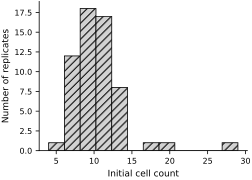

In [9]:
data_IC = P12[0]  # Observed initial states

# Plot a histogram of the IC
fig, ax = new_figure("half_standard")
ax.hist(data_IC, bins=12, facecolor="0.82", edgecolor="black", hatch="///")
ax.set_xlabel("Initial cell count")
ax.set_ylabel("Number of replicates")
finalize_axes(ax, keep_box=False)
plt.show()

The observed initial counts range from 4 to 29 cells. We approximate their logarithms by a Gaussian distribution. Exponentiating a draw from this fitted Gaussian produces a positive initial state for each simulated trajectory.

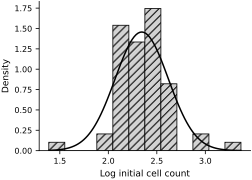

In [10]:
log_IC = jnp.log(data_IC)  # Log-transform the initial states

IC_mean = jnp.mean(log_IC)
IC_std = jnp.std(log_IC)

# Plot a histogram of the log-transformed IC with the normal distribution
fig, ax = new_figure("half_standard")
ax.hist(
    log_IC, bins=12, facecolor="0.82", edgecolor="black",
    hatch="///", density=True,
)
ax.set_xlabel("Log initial cell count")
ax.set_ylabel("Density")
x = jnp.linspace(jnp.min(log_IC), jnp.max(log_IC), 100)
y = jss.norm.pdf(x, IC_mean, IC_std)
ax.plot(x, y, color="black", linewidth=1.5)
finalize_axes(ax, keep_box=False)
plt.show()

## Population predictive check

We now draw initial states from this fitted distribution and propagate 1,000 trajectories with the exact log-space transition. The estimated parameters are held fixed, so the resulting interval represents initial-state and process variation but not parameter uncertainty.

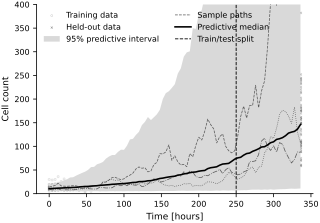

In [11]:
# Simulate exact log-space transitions over the full time grid.
dt_full = jnp.diff(t12)
n_samples = 1000
initial_key, innovation_key = jr.split(jr.PRNGKey(2025))
Y0_samples = IC_mean + IC_std * jr.normal(initial_key, (n_samples,))
innovations = jr.normal(innovation_key, (len(dt_full), n_samples))
theta12_train = mu12_train - 0.5 * sigma12_train**2
log_increments = (
    theta12_train * dt_full[:, None]
    + sigma12_train * jnp.sqrt(dt_full)[:, None] * innovations
)
log_paths = jnp.concatenate(
    (Y0_samples[None, :], Y0_samples[None, :] + jnp.cumsum(log_increments, axis=0)),
    axis=0,
)
X12_sims = jnp.exp(log_paths)

# Compute summary statistics
X12_median = jnp.median(X12_sims, axis=1)
X12_lower = jnp.quantile(X12_sims, 0.025, axis=1)
X12_upper = jnp.quantile(X12_sims, 0.975, axis=1)

# Plot the results
fig, ax = new_figure("full_standard")
ax.scatter(
    np.repeat(np.asarray(train_t12), train_P12.shape[1]), np.asarray(train_P12).ravel(),
    marker="o", s=4, facecolors="none", edgecolors="0.55", linewidths=0.4,
    alpha=0.55, rasterized=True, label="Training data",
)
ax.scatter(
    np.repeat(np.asarray(test_t12), test_P12.shape[1]), np.asarray(test_P12).ravel(),
    marker="x", s=4, color="0.15", linewidths=0.45, alpha=0.6,
    rasterized=True, label="Held-out data",
)
ax.fill_between(
    t12, X12_lower, X12_upper, color="0.85", linewidth=0,
    label="95% predictive interval",
)
for i, linestyle in enumerate(("--", ":", "-.")):
    ax.plot(
        t12, X12_sims[:, i], color="0.35", linestyle=linestyle,
        linewidth=0.75, label="Sample paths" if i == 0 else None,
    )
ax.plot(t12, X12_median, color="black", linewidth=1.6, label="Predictive median")
ax.axvline(250, color="black", linestyle="--", linewidth=0.9, label="Train/test split")
ax.set_xlabel("Time [hours]")
ax.set_ylim(0, 400)
ax.set_ylabel("Cell count")
ax.legend(ncol=2, loc="upper left")
finalize_axes(ax, keep_box=False)
plt.show()

The predictive median follows the population-level trend, but the simulated sample paths do not resemble individual experimental trajectories. This discrepancy is useful: matching an average trend does not establish that a stochastic model reproduces the underlying dynamics. The richer discrete models compared by {cite:t}`johnson2019cancer` address biological behavior that this GBM baseline omits.

## Exercises

1. Starting from the Gaussian transition for $Y_t=\log X_t$, derive the conditional mean and variance of $X_{t+h}\mid X_t=x$. Compare their small-$h$ expansions with the Euler--Maruyama conditional mean and variance.
2. For a direct Euler--Maruyama step, derive the probability that $X_{t+h}<0$ when $X_t=x>0$. How does this probability depend on $h$, $\mu$, and $\sigma$?
3. Repeat the predictive check with a different training cutoff. Explain which features of the result reflect initial-state variation, process variation, and the decision to hold the fitted parameters fixed.